<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 785 | Val: 192 | Test: 766


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Epoch   1/100 | LR: 3.16e-04 | train loss 1.0449 acc 0.564 | val loss 0.7163 acc 0.646 *


[DenseNet-121] Epoch   2/100 | LR: 3.16e-04 | train loss 0.9992 acc 0.637 | val loss 0.7853 acc 0.755


[DenseNet-121] Epoch   3/100 | LR: 3.16e-04 | train loss 0.9568 acc 0.637 | val loss 0.7411 acc 0.740


[DenseNet-121] Epoch   4/100 | LR: 3.16e-04 | train loss 0.8865 acc 0.692 | val loss 0.7129 acc 0.667 *


[DenseNet-121] Epoch   5/100 | LR: 3.16e-04 | train loss 0.8604 acc 0.683 | val loss 2.5298 acc 0.401


...

[DenseNet-121] Epoch  15/100 | LR: 3.16e-04 | train loss 0.7669 acc 0.724 | val loss 0.5139 acc 0.766


[DenseNet-121] Epoch  16/100 | LR: 3.16e-04 | train loss 0.6506 acc 0.764 | val loss 0.5784 acc 0.729


[DenseNet-121] Epoch  17/100 | LR: 3.16e-04 | train loss 0.7256 acc 0.768 | val loss 0.5024 acc 0.792


[DenseNet-121] Epoch  18/100 | LR: 3.16e-04 | train loss 0.6752 acc 0.768 | val loss 0.5596 acc 0.740


[DenseNet-121] Epoch  19/100 | LR: 3.16e-04 | train loss 0.7371 acc 0.740 | val loss 0.7306 acc 0.682

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 19.

[DenseNet-121] Restored best checkpoint (val loss = 0.5003)


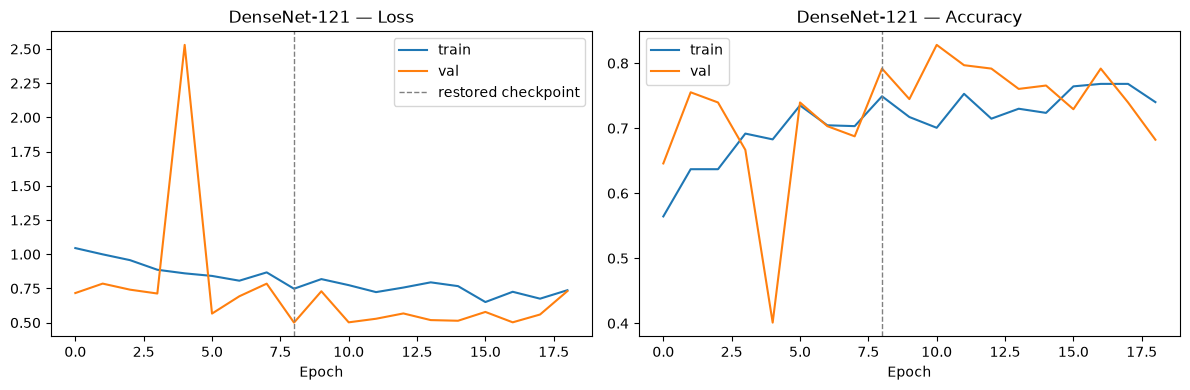

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.358


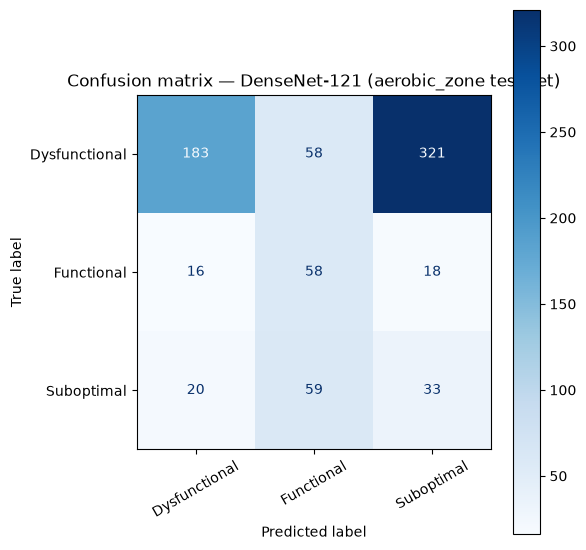

               precision    recall  f1-score   support

Dysfunctional      0.836     0.326     0.469       562
   Functional      0.331     0.630     0.434        92
   Suboptimal      0.089     0.295     0.136       112

     accuracy                          0.358       766
    macro avg      0.419     0.417     0.346       766
 weighted avg      0.666     0.358     0.416       766



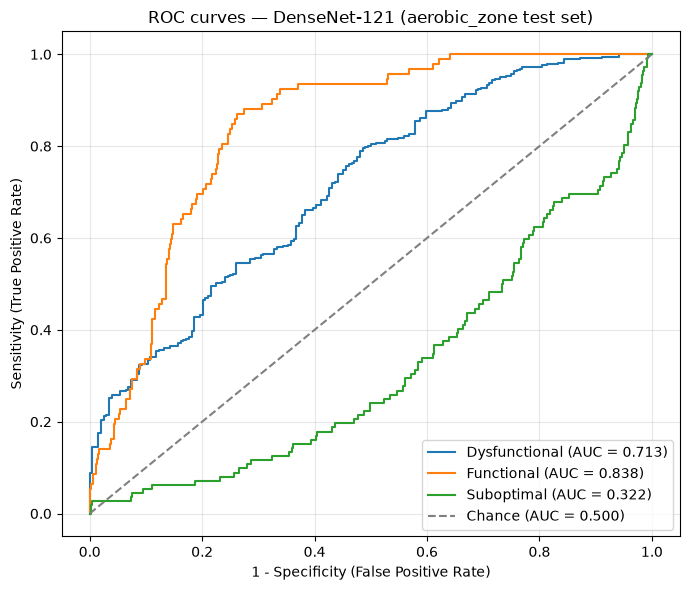

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.713
  Functional     : 0.838
  Suboptimal     : 0.322

Mean AUC (over 3/3 classes with test examples): 0.624


(np.float64(0.3577023498694517),
 {'Dysfunctional': 0.7130346800641965,
  'Functional': 0.8377789962585473,
  'Suboptimal': 0.32198831367409353})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_densenet121_CapeFlats.pkl


Saved model weights to ../models/aerobic_zone_densenet121_cnn.pt
